In [ ]:
import pandas as pd

# Read as tab-separated (very important!)
df = pd.read_csv("/content/train.txt",
                 sep="\t",
                 encoding="utf-8")

df.head()

,uid,text,label
0,4330,nen á vist bolest vztek smutek ज़मातेक ोसम ě lo...,1
1,41616,हाँ यार नेहा कब करेगा वह पोस्ट उसने न सच में p...,1
2,6648,television media congress के लिए नही ह . ये तो...,0
3,2512,आल इंडिया me ंर्क लागु करे w कश्मीर से dhara 3...,2
4,610,who पागल है क्या ? They aren ’ t real issues M...,1


In [ ]:
df.shape

(14000, 3)

In [ ]:
# Drop the id column (we don't need it for modeling)
df = df.drop(columns=["uid"])

# Inspect labels
print(df["label"].value_counts())

# Make sure labels are integers 0 / 1 / 2
df["label"] = df["label"].astype(int)

# For clarity, rename to label_id
df = df.rename(columns={"label": "label_id"})

df.head()

label
1    5264
2    4634
0    4102
Name: count, dtype: int64


,text,label_id
0,nen á vist bolest vztek smutek ज़मातेक ोसम ě lo...,1
1,हाँ यार नेहा कब करेगा वह पोस्ट उसने न सच में p...,1
2,television media congress के लिए नही ह . ये तो...,0
3,आल इंडिया me ंर्क लागु करे w कश्मीर से dhara 3...,2
4,who पागल है क्या ? They aren ’ t real issues M...,1


In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# English + (if available) Hindi stopwords + some Hinglish fillers
en_stop = set(stopwords.words('english'))
try:
    hi_stop = set(stopwords.words('hindi'))
except:
    hi_stop = set()

extra_hinglish = {
    'hai', 'hain', 'hu', 'tha', 'thi', 'the',
    'raha', 'rahe', 'rha', 'rhe',
    'kr', 'kar', 'karo', 'krna', 'krne',
    'na', 'nahi', 'nai',
    'haan', 'han', 'yaar', 'yr',
    'toh', 'tho', 'ab',
    'bhai', 'sir', 'madam', 'ji'
}

stop_words = en_stop | hi_stop | extra_hinglish

url_pattern = re.compile(r'http\S+|www\.\S+')
mention_pattern = re.compile(r'@\w+')
hashtag_pattern = re.compile(r'#\w+')
number_pattern = re.compile(r'\d+')
repeat_pattern = re.compile(r'(.)\1{2,}', re.DOTALL)

def clean_hinglish(text: str) -> str:
    text = str(text)

    # lower-case
    text = text.lower()

    # remove urls, mentions, hashtags
    text = url_pattern.sub(' ', text)
    text = mention_pattern.sub(' ', text)
    text = hashtag_pattern.sub(' ', text)

    # remove numbers
    text = number_pattern.sub(' ', text)

    # normalize aaa → aa
    text = repeat_pattern.sub(r'\1\1', text)

    # remove punctuation except Indic + spaces + emojis
    text = re.sub(r'[^a-z\u0900-\u097F\u0980-\u09FF\s🙂-🙃😀-🙏😡-😿]', ' ', text)

    # tokenize + remove stopwords + very short tokens
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 2]

    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df["clean_text"] = df["text"].apply(clean_hinglish)
df[["text", "clean_text", "label_id"]].head()

,text,clean_text,label_id
0,nen á vist bolest vztek smutek ज़मातेक ोसम ě lo...,nen vist bolest vztek smutek ज़मातेक ोसम lost b...,1
1,हाँ यार नेहा कब करेगा वह पोस्ट उसने न सच में p...,हाँ यार नेहा करेगा पोस्ट उसने में photoshoot क...,1
2,television media congress के लिए नही ह . ये तो...,television media congress लिए नही तोह आपको पता...,0
3,आल इंडिया me ंर्क लागु करे w कश्मीर से dhara 3...,इंडिया ंर्क लागु करे कश्मीर dhara ख़तम करे इंडि...,2
4,who पागल है क्या ? They aren ’ t real issues M...,पागल क्या real issues mandir important hindu ख...,1


In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label_id"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 11200
Test size: 2800


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=5,
    sublinear_tf=True
)

vectorizer = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

((11200, 61644), (2800, 61644))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Linear SVM": LinearSVC(),
    "Multinomial NB": MultinomialNB()
}

results = []

for name, model in models.items():
    print("\n" + "="*70)
    print(f"Training: {name}")

    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")
    f1_weighted = f1_score(y_test, preds, average="weighted")

    print(f"Accuracy:      {acc:.4f}")
    print(f"F1 Macro:      {f1_macro:.4f}")
    print(f"F1 Weighted:   {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_test, preds,
        target_names=["Negative", "Neutral", "Positive"]
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })


Training: Logistic Regression
Accuracy:      0.5861
F1 Macro:      0.5910
F1 Weighted:   0.5875

Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.62      0.61       820
     Neutral       0.51      0.55      0.53      1053
    Positive       0.66      0.60      0.63       927

    accuracy                           0.59      2800
   macro avg       0.59      0.59      0.59      2800
weighted avg       0.59      0.59      0.59      2800

Confusion Matrix:
[[505 266  49]
 [232 582 239]
 [ 86 287 554]]

Training: Linear SVM
Accuracy:      0.5639
F1 Macro:      0.5678
F1 Weighted:   0.5642

Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.61      0.59       820
     Neutral       0.51      0.51      0.51      1053
    Positive       0.62      0.58      0.60       927

    accuracy                           0.56      2800
   macro avg       0.57      0.57      0.57      2

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.586071,0.591021,0.587459
1,Linear SVM,0.563929,0.567831,0.564206
2,Multinomial NB,0.573571,0.574568,0.567763


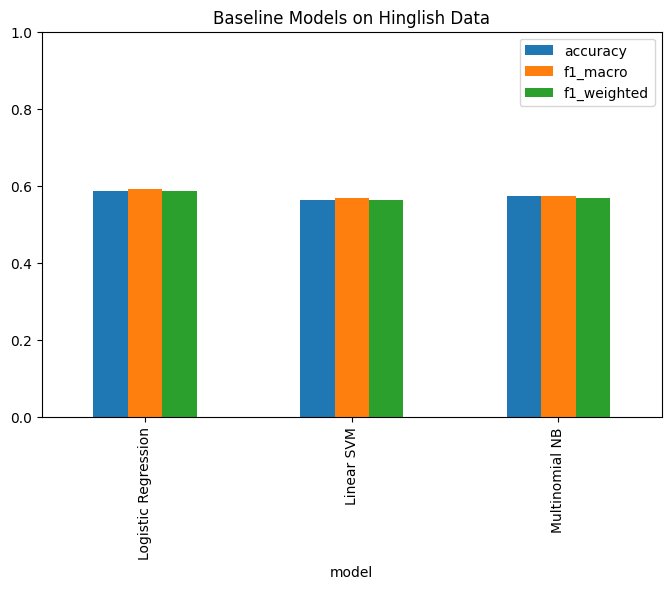

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("model")[["accuracy","f1_macro","f1_weighted"]].plot(
    kind="bar", figsize=(8,5)
)
plt.ylim(0,1)
plt.title("Baseline Models on Hinglish Data")
plt.show()

#transformers

In [ ]:
!pip install -q transformers indic-transliteration

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
X = df["clean_text"].astype(str).values
y = df["label_id"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)

(11200, 2800)

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }
        return item

#xlm roberta

In [ ]:
model_name = "xlm-roberta-base"  # you can later try others

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3   # negative, neutral, positive
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
device

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


device(type='cuda')

In [ ]:
train_dataset = TextDataset(X_train, y_train, tokenizer, max_length=64)
test_dataset  = TextDataset(X_test,  y_test,  tokenizer, max_length=64)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [ ]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        model.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


def eval_model(model, data_loader, device):
    model.eval()
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1_macro = f1_score(labels_all, preds_all, average="macro")
    f1_weighted = f1_score(labels_all, preds_all, average="weighted")
    report = classification_report(
        labels_all,
        preds_all,
        target_names=["Negative", "Neutral", "Positive"]
    )
    return acc, f1_macro, f1_weighted, report

In [ ]:
epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

for epoch in range(epochs):
    print(f"\n===== Epoch {epoch+1}/{epochs} =====")
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"Train loss: {train_loss:.4f}")

    acc, f1_macro, f1_weighted, report = eval_model(model, test_loader, device)
    print(f"Validation accuracy:  {acc:.4f}")
    print(f"Validation F1 macro:  {f1_macro:.4f}")
    print(f"Validation F1 weighted: {f1_weighted:.4f}")
    print("\nClassification report:\n", report)


===== Epoch 1/3 =====
Train loss: 0.9897
Validation accuracy:  0.5743
Validation F1 macro:  0.5595
Validation F1 weighted: 0.5484

Classification report:
               precision    recall  f1-score   support

    Negative       0.55      0.75      0.63       820
     Neutral       0.57      0.28      0.38      1053
    Positive       0.60      0.75      0.67       927

    accuracy                           0.57      2800
   macro avg       0.57      0.59      0.56      2800
weighted avg       0.57      0.57      0.55      2800


===== Epoch 2/3 =====
Train loss: 0.8539
Validation accuracy:  0.5936
Validation F1 macro:  0.5878
Validation F1 weighted: 0.5785

Classification report:
               precision    recall  f1-score   support

    Negative       0.55      0.81      0.65       820
     Neutral       0.57      0.36      0.44      1053
    Positive       0.67      0.67      0.67       927

    accuracy                           0.59      2800
   macro avg       0.60      0.61  

In [ ]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

def deva_to_roman(text: str) -> str:
    text = str(text)
    # transliterate only Devanagari portion; other chars stay as-is
    try:
        return transliterate(text, sanscript.DEVANAGARI, sanscript.ITRANS)
    except Exception:
        return text

df["translit_text"] = df["text"].apply(deva_to_roman)
df[["text", "translit_text"]].head()

,text,translit_text
0,nen á vist bolest vztek smutek ज़मातेक ोसम ě lo...,nen á vist bolest vztek smutek zamAteka osama ...
1,हाँ यार नेहा कब करेगा वह पोस्ट उसने न सच में p...,hA.N yAra nehA kaba karegA vaha posTa usane na...
2,television media congress के लिए नही ह . ये तो...,television media congress ke lie nahI ha . ye ...
3,आल इंडिया me ंर्क लागु करे w कश्मीर से dhara 3...,Ala iMDiyA me Mrka lAgu kare w kashmIra se dha...
4,who पागल है क्या ? They aren ’ t real issues M...,who pAgala hai kyA ? They aren ’ t real issues...


In [ ]:
df["translit_clean"] = df["translit_text"].apply(clean_hinglish)
df[["clean_text", "translit_clean"]].head()

,clean_text,translit_clean
0,nen vist bolest vztek smutek ज़मातेक ोसम lost b...,nen vist bolest vztek smutek zamateka osama lo...
1,हाँ यार नेहा करेगा पोस्ट उसने में photoshoot क...,yara neha kaba karega vaha posta usane sacha m...
2,television media congress लिए नही तोह आपको पता...,television media congress lie toha apako pata ...
3,इंडिया ंर्क लागु करे कश्मीर dhara ख़तम करे इंडि...,ala imdiya mrka lagu kare kashmira dhara katam...
4,पागल क्या real issues mandir important hindu ख...,pagala kya real issues mandir important hindu ...


In [ ]:
X_t = df["translit_clean"].astype(str).values
y_t = df["label_id"].values

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t,
    test_size=0.2,
    random_state=42,
    stratify=y_t
)

train_dataset_t = TextDataset(X_train_t, y_train_t, tokenizer, max_length=64)
test_dataset_t  = TextDataset(X_test_t,  y_test_t,  tokenizer, max_length=64)

train_loader_t = DataLoader(train_dataset_t, batch_size=16, shuffle=True)
test_loader_t  = DataLoader(test_dataset_t,  batch_size=32, shuffle=False)

In [ ]:
model_t = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
).to(device)

optimizer_t = AdamW(model_t.parameters(), lr=2e-5)
total_steps_t = len(train_loader_t) * epochs
scheduler_t = get_linear_schedule_with_warmup(
    optimizer_t,
    num_warmup_steps=int(0.1 * total_steps_t),
    num_training_steps=total_steps_t
)

for epoch in range(epochs):
    print(f"\n===== Transliteration Exp – Epoch {epoch+1}/{epochs} =====")
    train_loss_t = train_epoch(model_t, train_loader_t, optimizer_t, scheduler_t, device)
    print(f"Train loss: {train_loss_t:.4f}")

    acc_t, f1_macro_t, f1_weighted_t, report_t = eval_model(model_t, test_loader_t, device)
    print(f"Validation accuracy:  {acc_t:.4f}")
    print(f"Validation F1 macro:  {f1_macro_t:.4f}")
    print(f"Validation F1 weighted: {f1_weighted_t:.4f}")
    print("\nClassification report:\n", report_t)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Transliteration Exp – Epoch 1/3 =====
Train loss: 1.0851


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Validation accuracy:  0.3761
Validation F1 macro:  0.1822
Validation F1 weighted: 0.2056

Classification report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       820
     Neutral       0.38      1.00      0.55      1053
    Positive       0.00      0.00      0.00       927

    accuracy                           0.38      2800
   macro avg       0.13      0.33      0.18      2800
weighted avg       0.14      0.38      0.21      2800


===== Transliteration Exp – Epoch 2/3 =====
Train loss: 1.0977


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Validation accuracy:  0.3761
Validation F1 macro:  0.1822
Validation F1 weighted: 0.2056

Classification report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       820
     Neutral       0.38      1.00      0.55      1053
    Positive       0.00      0.00      0.00       927

    accuracy                           0.38      2800
   macro avg       0.13      0.33      0.18      2800
weighted avg       0.14      0.38      0.21      2800


===== Transliteration Exp – Epoch 3/3 =====
Train loss: 1.0964
Validation accuracy:  0.3761
Validation F1 macro:  0.1822
Validation F1 weighted: 0.2056

Classification report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       820
     Neutral       0.38      1.00      0.55      1053
    Positive       0.00      0.00      0.00       927

    accuracy                           0.38      2800
   macro avg       0.13      0.33      0.18      2800
w

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results_phase2 = pd.DataFrame([
    {
        "setup": "XLM-R (no transliteration)",
        "accuracy":  acc,
        "f1_macro":  f1_macro,
        "f1_weighted": f1_weighted
    },
    {
        "setup": "XLM-R (Devanagari→Roman translit)",
        "accuracy":  acc_t,
        "f1_macro":  f1_macro_t,
        "f1_weighted": f1_weighted_t
    }
])
results_phase2

,setup,accuracy,f1_macro,f1_weighted
0,XLM-R (no transliteration),0.602500,0.604136,0.597583
1,XLM-R (Devanagari→Roman translit),0.376071,0.182196,0.205556


#MuRIL

In [ ]:
!pip install -q transformers indic-transliteration

import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

# helper: check if token already has Devanagari
def has_devanagari(text):
    return any('\u0900' <= ch <= '\u097F' for ch in str(text))

# transliterate only pure ASCII-word tokens, leave others
token_re = re.compile(r"(\s+)")  # to keep spaces when splitting

def roman_to_deva(text: str) -> str:
    text = str(text)
    parts = token_re.split(text)   # words + spaces
    new_parts = []

    for tok in parts:
        if tok.isspace() or tok == "":
            new_parts.append(tok)
            continue

        # already Devanagari → keep
        if has_devanagari(tok):
            new_parts.append(tok)
            continue

        # pure latin letters (Hinglish word) → transliterate
        if re.fullmatch(r"[A-Za-z']+", tok):
            try:
                deva_tok = transliterate(tok, sanscript.ITRANS, sanscript.DEVANAGARI)
            except Exception:
                deva_tok = tok
            new_parts.append(deva_tok)
        else:
            new_parts.append(tok)

    return "".join(new_parts)

# apply on your clean_text
df["indic_text"] = df["clean_text"].apply(roman_to_deva)
df[["clean_text", "indic_text"]].head()

,clean_text,indic_text
0,nen vist bolest vztek smutek ज़मातेक ोसम lost b...,नेन् विस्त् बोलेस्त् व्ज़्तेक् स्मुतेक् ज़मातेक ...
1,हाँ यार नेहा करेगा पोस्ट उसने में photoshoot क...,हाँ यार नेहा करेगा पोस्ट उसने में फोतोशूत् करन...
2,television media congress लिए नही तोह आपको पता...,तेलेविसिओन् मेदिअ चोन्ग्रेस्स् लिए नही तोह आपक...
3,इंडिया ंर्क लागु करे कश्मीर dhara ख़तम करे इंडि...,इंडिया ंर्क लागु करे कश्मीर धर ख़तम करे इंडियन ...
4,पागल क्या real issues mandir important hindu ख...,पागल क्या रेअल् इस्सुएस् मन्दिर् इम्पोर्तन्त् ...


In [ ]:
X_indic = df["indic_text"].astype(str).values
y = df["label_id"].values

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_indic, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train_i), len(X_test_i)

(11200, 2800)

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }

model_name = "google/muril-base-cased"   # MuRIL (public, Hindi-centric)

tokenizer_i = AutoTokenizer.from_pretrained(model_name)
model_i = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
).to(device)

train_dataset_i = TextDataset(X_train_i, y_train_i, tokenizer_i, max_length=64)
test_dataset_i  = TextDataset(X_test_i,  y_test_i,  tokenizer_i, max_length=64)

train_loader_i = DataLoader(train_dataset_i, batch_size=16, shuffle=True)
test_loader_i  = DataLoader(test_dataset_i,  batch_size=32, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        model.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


def eval_model(model, data_loader, device):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1_macro = f1_score(labels_all, preds_all, average="macro")
    f1_weighted = f1_score(labels_all, preds_all, average="weighted")
    report = classification_report(
        labels_all, preds_all,
        target_names=["Negative", "Neutral", "Positive"]
    )
    return acc, f1_macro, f1_weighted, report

In [ ]:
epochs = 3
optimizer_i = AdamW(model_i.parameters(), lr=2e-5)

total_steps_i = len(train_loader_i) * epochs
scheduler_i = get_linear_schedule_with_warmup(
    optimizer_i,
    num_warmup_steps=int(0.1 * total_steps_i),
    num_training_steps=total_steps_i
)

best_metrics = None

for epoch in range(epochs):
    print(f"\n===== IndicBERT Roman→Devanagari | Epoch {epoch+1}/{epochs} =====")
    train_loss_i = train_epoch(model_i, train_loader_i, optimizer_i, scheduler_i, device)
    print(f"Train loss: {train_loss_i:.4f}")

    acc_i, f1_m_i, f1_w_i, report_i = eval_model(model_i, test_loader_i, device)
    print(f"Validation accuracy:    {acc_i:.4f}")
    print(f"Validation F1 (macro):  {f1_m_i:.4f}")
    print(f"Validation F1 (weighted): {f1_w_i:.4f}")
    print("\nClassification report:\n", report_i)

    best_metrics = (acc_i, f1_m_i, f1_w_i, report_i)


===== IndicBERT Roman→Devanagari | Epoch 1/3 =====
Train loss: 1.0019
Validation accuracy:    0.5586
Validation F1 (macro):  0.5591
Validation F1 (weighted): 0.5549

Classification report:
               precision    recall  f1-score   support

    Negative       0.67      0.50      0.57       820
     Neutral       0.48      0.46      0.47      1053
    Positive       0.57      0.72      0.64       927

    accuracy                           0.56      2800
   macro avg       0.57      0.56      0.56      2800
weighted avg       0.56      0.56      0.55      2800


===== IndicBERT Roman→Devanagari | Epoch 2/3 =====
Train loss: 0.8470
Validation accuracy:    0.5736
Validation F1 (macro):  0.5747
Validation F1 (weighted): 0.5674

Classification report:
               precision    recall  f1-score   support

    Negative       0.62      0.64      0.63       820
     Neutral       0.51      0.42      0.46      1053
    Positive       0.59      0.70      0.64       927

    accuracy       

In [ ]:
acc_i, f1_m_i, f1_w_i, _ = best_metrics
print("MuRil (Roman→Devanagari) summary:")
print("Accuracy   :", acc_i)
print("F1 macro   :", f1_m_i)
print("F1 weighted:", f1_w_i)

IndicBERT (Roman→Devanagari) summary:
Accuracy   : 0.6003571428571428
F1 macro   : 0.6060378528108316
F1 weighted: 0.6022171016743518


In [ ]:
results_phase2 = pd.DataFrame([
    {
        "setup": "XLM-R (no transliteration)",
        "accuracy": 0.6025,
        "f1_macro": 0.604136,
        "f1_weighted": 0.597583
    },
    {
        "setup": "XLM-R (Devanagari→Roman)",
        "accuracy": 0.376071,
        "f1_macro": 0.182196,
        "f1_weighted": 0.205556
    },
    {
        "setup": "MuRIL (Roman→Devanagari)",
        "accuracy": acc_i,
        "f1_macro": f1_m_i,
        "f1_weighted": f1_w_i
    }
])

results_phase2

,setup,accuracy,f1_macro,f1_weighted
0,XLM-R (no transliteration),0.602500,0.604136,0.597583
1,XLM-R (Devanagari→Roman),0.376071,0.182196,0.205556
2,MuRIL (Roman→Devanagari),0.600357,0.606038,0.602217
